# Employee Attrition Risk Prediction

## Goal

The goal of this notebook is to build a supervised machine learning model that predicts whether an employee is likely to leave the company.

Employee attrition is an important business problem because losing employees can increase hiring costs, training costs, workload pressure, and knowledge loss.

This notebook uses HR data to predict attrition risk and understand which employee-related factors are most associated with leaving.

The notebook covers:

- Loading a Kaggle dataset with KaggleHub
- Inspecting HR employee data
- Exploratory data analysis
- Feature cleaning and leakage prevention
- Train-test splitting
- Preprocessing numerical and categorical features
- Comparing multiple classification models
- Evaluating accuracy, precision, recall, F1-score, ROC-AUC, and PR-AUC
- Tuning the classification threshold
- Interpreting feature importance
- Grouping employees into attrition risk bands
- Producing HR-style retention insights

In [1]:
import os
import warnings
from pathlib import Path

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)

c:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.4.0) or chardet (7.4.3)/charset_normalizer (3.4.2) doesn't match a supported version!
  warnings.warn(


## Setup

This notebook uses scikit-learn for supervised binary classification.

The target variable is employee attrition:

- `No`: employee stayed
- `Yes`: employee left

Because attrition is usually less common than staying, this notebook evaluates the model using more than accuracy. Recall, precision, F1-score, ROC-AUC, and PR-AUC are also used.

In [2]:
path = kagglehub.dataset_download("pavansubhasht/ibm-hr-analytics-attrition-dataset")

print("Dataset downloaded to:", path)
print("Files:")
print(os.listdir(path))

100%|██████████| 50.1k/50.1k [00:00<00:00, 257kB/s]

Extracting files...
Dataset downloaded to: C:\Users\ADMIN\.cache\kagglehub\datasets\pavansubhasht\ibm-hr-analytics-attrition-dataset\versions\1
Files:
['WA_Fn-UseC_-HR-Employee-Attrition.csv']


In [3]:
path = Path(path)

csv_files = list(path.glob("*.csv"))
csv_files

[WindowsPath('C:/Users/ADMIN/.cache/kagglehub/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset/versions/1/WA_Fn-UseC_-HR-Employee-Attrition.csv')]

In [5]:
df = pd.read_csv(csv_files[0])

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


## Dataset

This notebook uses the IBM HR Analytics Employee Attrition & Performance dataset from Kaggle.

Each row represents one employee.

The dataset contains employee demographic, job-related, satisfaction, compensation, and work history variables.

The target variable is `Attrition`, which indicates whether the employee left the company.

In [6]:
df.describe(include="all")

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470,1470,1470.000000,1470,1470.000000,1470.000000,1470,1470.0,1470.000000,1470.000000,1470,1470.000000,1470.000000,1470.000000,1470,1470.000000,1470,1470.000000,1470.000000,1470.000000,1470,1470,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
unique,NaN,2,3,NaN,3,NaN,NaN,6,NaN,NaN,NaN,2,NaN,NaN,NaN,9,NaN,3,NaN,NaN,NaN,1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,No,Travel_Rarely,NaN,Research & Development,NaN,NaN,Life Sciences,NaN,NaN,NaN,Male,NaN,NaN,NaN,Sales Executive,NaN,Married,NaN,NaN,NaN,Y,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1233,1043,NaN,961,NaN,NaN,606,NaN,NaN,NaN,882,NaN,NaN,NaN,326,NaN,673,NaN,NaN,NaN,1470,1054,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,36.923810,NaN,NaN,802.485714,NaN,9.192517,2.912925,NaN,1.0,1024.865306,2.721769,NaN,65.891156,2.729932,2.063946,NaN,2.728571,NaN,6502.931293,14313.103401,2.693197,NaN,NaN,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,NaN,NaN,403.509100,NaN,8.106864,1.024165,NaN,0.0,602.024335,1.093082,NaN,20.329428,0.711561,1.106940,NaN,1.102846,NaN,4707.956783,7117.786044,2.498009,NaN,NaN,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,NaN,NaN,102.000000,NaN,1.000000,1.000000,NaN,1.0,1.000000,1.000000,NaN,30.000000,1.000000,1.000000,NaN,1.000000,NaN,1009.000000,2094.000000,0.000000,NaN,NaN,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,NaN,NaN,465.000000,NaN,2.000000,2.000000,NaN,1.0,491.250000,2.000000,NaN,48.000000,2.000000,1.000000,NaN,2.000000,NaN,2911.000000,8047.000000,1.000000,NaN,NaN,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,NaN,NaN,802.000000,NaN,7.000000,3.000000,NaN,1.0,1020.500000,3.000000,NaN,66.000000,3.000000,2.000000,NaN,3.000000,NaN,4919.000000,14235.500000,2.000000,NaN,NaN,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,NaN,NaN,1157.000000,NaN,14.000000,4.000000,NaN,1.0,1555.750000,4.000000,NaN,83.750000,3.000000,3.000000,NaN,4.000000,NaN,8379.000000,20461.500000,4.000000,NaN,NaN,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000


In [7]:
print("Shape:", df.shape)
df.info()

Shape: (1470, 35)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLev

In [8]:
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [9]:
df["Attrition"].value_counts(normalize=True)

Attrition
No     0.838776
Yes    0.161224
Name: proportion, dtype: float64

## Initial Data Inspection

The dataset contains 1,470 employees and 35 columns.

The target variable is `Attrition`.

The attrition distribution is:

- Stayed: 1,233 employees, or 83.88%
- Left: 237 employees, or 16.12%

There are no missing values in the dataset.

The dataset contains a mix of numerical and categorical features, including age, business travel, department, job role, monthly income, overtime, satisfaction scores, distance from home, and years at the company.

Some columns are not useful for modelling. `EmployeeNumber` is an identifier, while `EmployeeCount`, `Over18`, and `StandardHours` are constant columns. These columns are removed later during feature cleaning.

The target distribution is imbalanced because employees who left are the minority class. This means accuracy alone is not enough for evaluation, so the notebook also uses recall, precision, F1-score, ROC-AUC, and PR-AUC.

In [10]:
attrition_rate = (
    df["Attrition"]
    .value_counts(normalize=True)
    .rename("proportion")
)

attrition_rate

Attrition
No     0.838776
Yes    0.161224
Name: proportion, dtype: float64

In [11]:
overtime_attrition = (
    df.groupby("OverTime")["Attrition"]
    .apply(lambda x: (x == "Yes").mean())
    .sort_values(ascending=False)
)

overtime_attrition

OverTime
Yes    0.305288
No     0.104364
Name: Attrition, dtype: float64

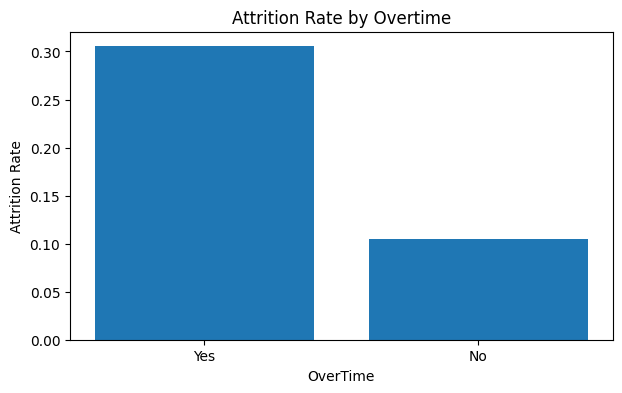

In [12]:
plt.figure(figsize=(7, 4))
plt.bar(overtime_attrition.index, overtime_attrition.values)
plt.title("Attrition Rate by Overtime")
plt.xlabel("OverTime")
plt.ylabel("Attrition Rate")
plt.show()

In [13]:
jobrole_attrition = (
    df.groupby("JobRole")["Attrition"]
    .agg(
        employees="count",
        attrition_rate=lambda x: (x == "Yes").mean()
    )
    .sort_values("attrition_rate", ascending=False)
)

jobrole_attrition

,employees,attrition_rate
JobRole,,
Sales Representative,83,0.397590
Laboratory Technician,259,0.239382
Human Resources,52,0.230769
Sales Executive,326,0.174847
Research Scientist,292,0.160959
Manufacturing Director,145,0.068966
Healthcare Representative,131,0.068702
Manager,102,0.049020
Research Director,80,0.025000


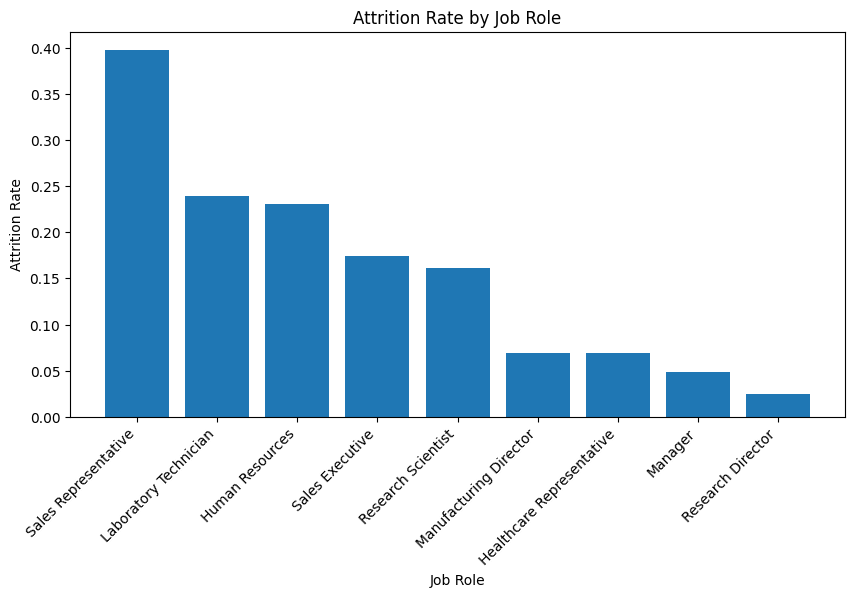

In [14]:
plt.figure(figsize=(10, 5))
plt.bar(jobrole_attrition.index, jobrole_attrition["attrition_rate"])
plt.title("Attrition Rate by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Attrition Rate")
plt.xticks(rotation=45, ha="right")
plt.show()

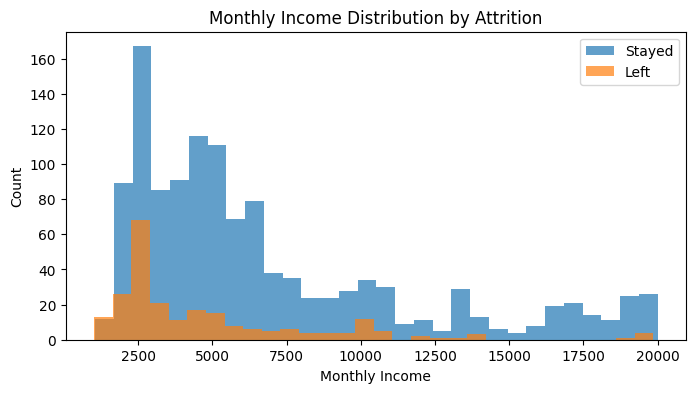

In [15]:
plt.figure(figsize=(8, 4))
plt.hist(df[df["Attrition"] == "No"]["MonthlyIncome"], bins=30, alpha=0.7, label="Stayed")
plt.hist(df[df["Attrition"] == "Yes"]["MonthlyIncome"], bins=30, alpha=0.7, label="Left")
plt.title("Monthly Income Distribution by Attrition")
plt.xlabel("Monthly Income")
plt.ylabel("Count")
plt.legend()
plt.show()

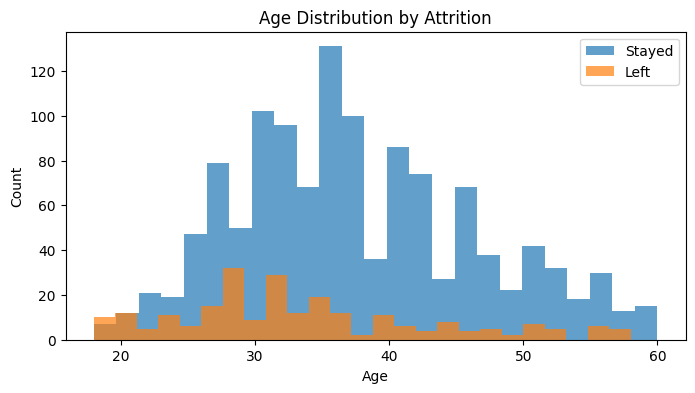

In [16]:
plt.figure(figsize=(8, 4))
plt.hist(df[df["Attrition"] == "No"]["Age"], bins=25, alpha=0.7, label="Stayed")
plt.hist(df[df["Attrition"] == "Yes"]["Age"], bins=25, alpha=0.7, label="Left")
plt.title("Age Distribution by Attrition")
plt.xlabel("Age")
plt.ylabel("Count")
plt.legend()
plt.show()

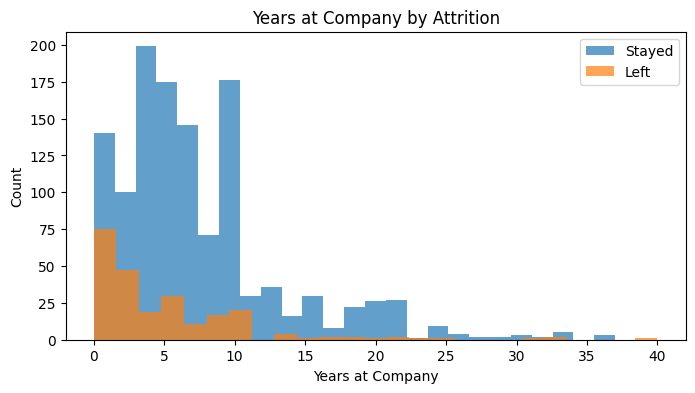

In [17]:
plt.figure(figsize=(8, 4))
plt.hist(df[df["Attrition"] == "No"]["YearsAtCompany"], bins=25, alpha=0.7, label="Stayed")
plt.hist(df[df["Attrition"] == "Yes"]["YearsAtCompany"], bins=25, alpha=0.7, label="Left")
plt.title("Years at Company by Attrition")
plt.xlabel("Years at Company")
plt.ylabel("Count")
plt.legend()
plt.show()

## Exploratory Data Analysis

The EDA section explores how attrition rate changes across important employee features.

Overtime shows a strong relationship with attrition. Employees who worked overtime had an attrition rate of 30.53%, while employees who did not work overtime had an attrition rate of 10.44%.

Attrition rate also varied by job role. The highest attrition rates were:

- Sales Representative: 39.76%
- Laboratory Technician: 23.94%
- Human Resources: 23.08%
- Sales Executive: 17.48%
- Research Scientist: 16.10%

The lowest attrition rates were:

- Research Director: 2.50%
- Manager: 4.90%
- Healthcare Representative: 6.87%
- Manufacturing Director: 6.90%

The income, age, and years-at-company plots suggest that attrition is more common among employees with lower income, younger employees, and employees with fewer years at the company.

Overall, the EDA suggests that attrition risk is related to workload, job role, compensation, career stage, and employee experience.

In [18]:
df_model = df.copy()

df_model["AttritionBinary"] = (df_model["Attrition"] == "Yes").astype(int)

target = "AttritionBinary"

drop_cols = [
    "Attrition",
    "EmployeeNumber"
]

# Remove constant columns if they exist
constant_cols = [
    col for col in df_model.columns
    if df_model[col].nunique() == 1
]

drop_cols = drop_cols + constant_cols

drop_cols

['Attrition', 'EmployeeNumber', 'EmployeeCount', 'Over18', 'StandardHours']

In [20]:
X = df_model.drop(columns=drop_cols + [target])
y = df_model[target]

X.shape, y.shape

((1470, 30), (1470,))

In [21]:
y.value_counts()

AttritionBinary
0    1233
1     237
Name: count, dtype: int64

## Target Setup and Feature Cleaning

The original target column `Attrition` is converted into a binary target:

- `0`: employee stayed
- `1`: employee left

The column `EmployeeNumber` is removed because it is only an identifier and should not help predict attrition.

Constant columns are also removed because they contain the same value for every employee and do not provide useful information for modelling.

This produces a clean supervised learning setup with employee features as inputs and attrition status as the prediction target.

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("Train target distribution:")
print(y_train.value_counts(normalize=True))

print("Test target distribution:")
print(y_test.value_counts(normalize=True))

Train shape: (1176, 30)
Test shape: (294, 30)
Train target distribution:
AttritionBinary
0    0.838435
1    0.161565
Name: proportion, dtype: float64
Test target distribution:
AttritionBinary
0    0.840136
1    0.159864
Name: proportion, dtype: float64


## Train-Test Split

The dataset is split into training and test sets.

Stratification is used so that the attrition rate is similar in both sets.

The training set is used for model fitting and cross-validation.

The test set is kept separate for final evaluation.

In [23]:
numeric_features = X_train.select_dtypes(include=["int64", "float64", "bool"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print("Number of numeric features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

Numeric features: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
Categorical features: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
Number of numeric features: 23
Number of categorical features: 7


In [24]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## Preprocessing

The dataset contains both numerical and categorical features.

Numerical features are median-imputed and standardized.

Categorical features are imputed using the most frequent value and one-hot encoded.

The preprocessing is placed inside a pipeline so that transformations are learned only from the training data during cross-validation and model fitting.

In [25]:
models = {
    "Dummy Baseline": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_iter=200,
        max_leaf_nodes=15,
        l2_regularization=0.1,
        random_state=42
    )
}

In [28]:
scoring = {
    "accuracy": "accuracy",
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
    "f1": "f1",
    "precision": "precision",
    "recall": "recall"
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_rows = []

for model_name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )
    
    cv_rows.append({
        "model": model_name,
        "accuracy_mean": scores["test_accuracy"].mean(),
        "roc_auc_mean": scores["test_roc_auc"].mean(),
        "pr_auc_mean": scores["test_average_precision"].mean(),
        "f1_mean": scores["test_f1"].mean(),
        "precision_mean": scores["test_precision"].mean(),
        "recall_mean": scores["test_recall"].mean()
    })

cv_results = pd.DataFrame(cv_rows).sort_values("roc_auc_mean", ascending=False)
cv_results

,model,accuracy_mean,roc_auc_mean,pr_auc_mean,f1_mean,precision_mean,recall_mean
1,Logistic Regression,0.753354,0.827286,0.605828,0.492471,0.372076,0.736842
3,HistGradientBoosting,0.871598,0.813929,0.574293,0.452179,0.734601,0.331579
2,Random Forest,0.864782,0.807286,0.565033,0.414389,0.679450,0.305263
0,Dummy Baseline,0.838435,0.500000,0.161565,0.000000,0.000000,0.000000


## Model Comparison with Cross-Validation

Several supervised classification models are compared using 5-fold stratified cross-validation.

The models are:

- Dummy baseline
- Logistic Regression
- Random Forest
- HistGradientBoosting

The dummy baseline achieved ROC-AUC of 0.5000 and F1-score of 0.0000, showing that it provides no useful attrition prediction ability.

Logistic Regression achieved the best overall cross-validation performance. It had the highest ROC-AUC of 0.8273, the highest PR-AUC of 0.6058, the highest F1-score of 0.4925, and the highest recall of 0.7368.

HistGradientBoosting achieved higher accuracy than Logistic Regression, with accuracy of 0.8716, but its recall was much lower at 0.3316. This means it missed more employees who actually left.

Random Forest also achieved strong accuracy, but its recall and F1-score were lower than Logistic Regression.

Because attrition is the minority class, recall and PR-AUC are important. Logistic Regression is selected as the final model because it provides the strongest balance for identifying employees at risk of leaving.

In [30]:
best_model_name = cv_results.iloc[0]["model"]
best_model_name

'Logistic Regression'

In [32]:
final_model = models[best_model_name]

final_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", final_model)
])

final_pipe.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Final Model Training

The final model is selected based on cross-validation ROC-AUC.

The selected model is Logistic Regression.

Logistic Regression achieved the highest cross-validation ROC-AUC of 0.8273 and the highest PR-AUC of 0.6058.

It also achieved the highest recall, which is useful for attrition prediction because the goal is to identify employees who may be at risk of leaving.

The final pipeline includes preprocessing and the Logistic Regression model. It is trained on the full training set and then evaluated on the untouched test set.

In [34]:
y_pred = final_pipe.predict(X_test)
y_proba = final_pipe.predict_proba(X_test)[:, 1]

test_metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, zero_division=0),
    "recall": recall_score(y_test, y_pred, zero_division=0),
    "f1": f1_score(y_test, y_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_proba),
    "pr_auc": average_precision_score(y_test, y_proba)
}

test_metrics

{'accuracy': 0.7517006802721088,
 'precision': 0.3488372093023256,
 'recall': 0.6382978723404256,
 'f1': 0.45112781954887216,
 'roc_auc': 0.8031699543457662,
 'pr_auc': 0.5612212444049638}

In [35]:
y_pred = final_pipe.predict(X_test)
y_proba = final_pipe.predict_proba(X_test)[:, 1]

test_metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred, zero_division=0),
    "recall": recall_score(y_test, y_pred, zero_division=0),
    "f1": f1_score(y_test, y_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_proba),
    "pr_auc": average_precision_score(y_test, y_proba)
}

test_metrics

{'accuracy': 0.7517006802721088,
 'precision': 0.3488372093023256,
 'recall': 0.6382978723404256,
 'f1': 0.45112781954887216,
 'roc_auc': 0.8031699543457662,
 'pr_auc': 0.5612212444049638}

In [36]:
print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

           0     0.9183    0.7733    0.8396       247
           1     0.3488    0.6383    0.4511        47

    accuracy                         0.7517       294
   macro avg     0.6336    0.7058    0.6453       294
weighted avg     0.8272    0.7517    0.7775       294



In [37]:
cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Actual Stayed", "Actual Left"],
    columns=["Predicted Stayed", "Predicted Left"]
)

cm_df

,Predicted Stayed,Predicted Left
Actual Stayed,191,56
Actual Left,17,30


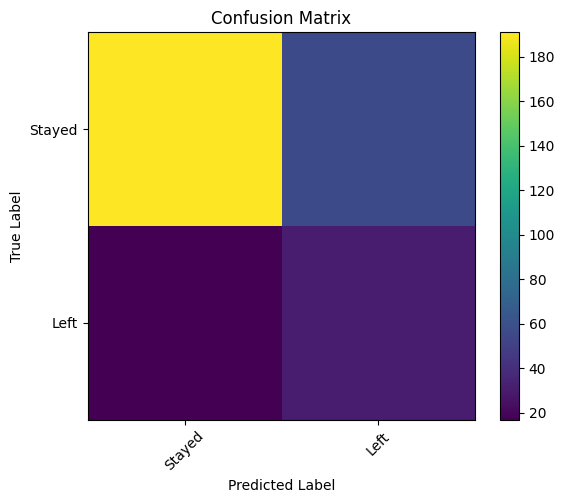

In [38]:
plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(2)
plt.xticks(tick_marks, ["Stayed", "Left"], rotation=45)
plt.yticks(tick_marks, ["Stayed", "Left"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

## Test Set Evaluation

The final Logistic Regression model is evaluated on the untouched test set.

The test set results are:

- Accuracy: 0.7517
- Precision: 0.3488
- Recall: 0.6383
- F1-score: 0.4511
- ROC-AUC: 0.8032
- PR-AUC: 0.5612

The confusion matrix shows that the model correctly classified 191 employees who stayed and 30 employees who left.

The model produced 56 false positives and 17 false negatives.

A false positive means the model predicted that an employee would leave, but the employee actually stayed. A false negative means the model predicted that an employee would stay, but the employee actually left.

The model has moderate recall for the attrition class, meaning it identifies a reasonable number of employees who left. However, precision is low, meaning many employees flagged as attrition risks did not actually leave.

This is a common trade-off in imbalanced HR prediction problems.

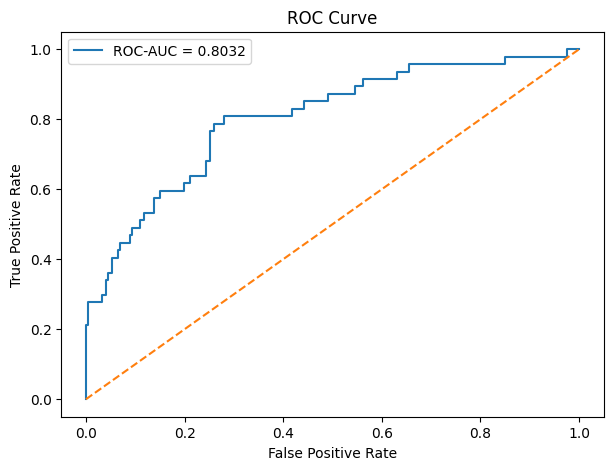

In [39]:
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {test_metrics['roc_auc']:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

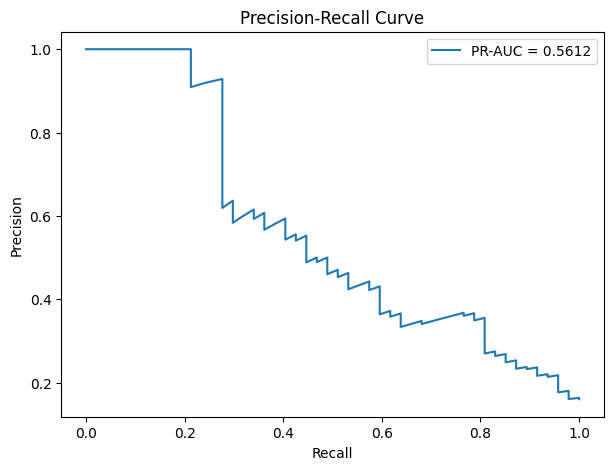

In [40]:
precision, recall, _ = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f"PR-AUC = {test_metrics['pr_auc']:.4f}")
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

## ROC and Precision-Recall Curves

The ROC curve shows the trade-off between true positive rate and false positive rate across different thresholds.

The Precision-Recall curve focuses more directly on the attrition class.

These curves are useful because the default classification threshold of 0.5 may not be the best threshold for HR decision-making.

In [41]:
threshold_rows = []

for threshold in np.arange(0.1, 0.91, 0.05):
    pred_threshold = (y_proba >= threshold).astype(int)
    
    threshold_rows.append({
        "threshold": threshold,
        "predicted_attrition": pred_threshold.sum(),
        "precision": precision_score(y_test, pred_threshold, zero_division=0),
        "recall": recall_score(y_test, pred_threshold, zero_division=0),
        "f1": f1_score(y_test, pred_threshold, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_rows)
threshold_df

,threshold,predicted_attrition,precision,recall,f1
0,0.10,223,0.201794,0.957447,0.333333
1,0.15,196,0.219388,0.914894,0.353909
2,0.20,179,0.234637,0.893617,0.371681
3,0.25,152,0.263158,0.851064,0.402010
4,0.30,134,0.283582,0.808511,0.419890
5,0.35,120,0.316667,0.808511,0.455090
6,0.40,106,0.349057,0.787234,0.483660
7,0.45,94,0.340426,0.680851,0.453901
8,0.50,86,0.348837,0.638298,0.451128
9,0.55,74,0.378378,0.595745,0.462810


In [42]:
best_f1_row = threshold_df.sort_values("f1", ascending=False).iloc[0]
best_f1_row

threshold               0.600000
predicted_attrition    62.000000
precision               0.435484
recall                  0.574468
f1                      0.495413
Name: 10, dtype: float64

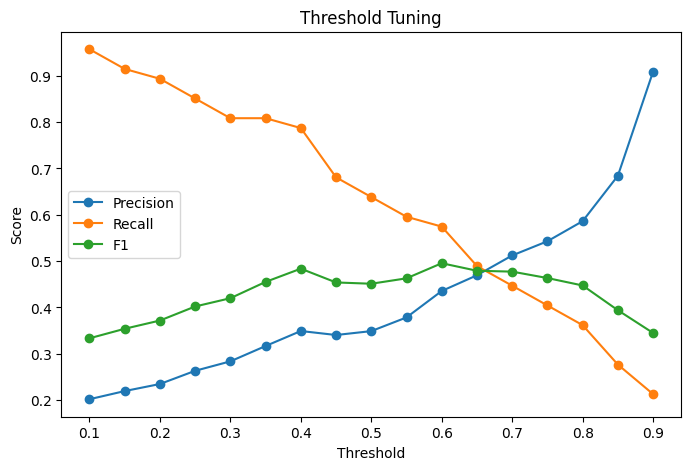

In [43]:
plt.figure(figsize=(8, 5))
plt.plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], marker="o", label="F1")
plt.title("Threshold Tuning")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.show()

## Threshold Tuning

The default threshold of 0.5 is not always the best threshold.

A lower threshold predicts more employees as attrition risks. This usually increases recall but lowers precision.

A higher threshold predicts fewer employees as attrition risks. This usually increases precision but lowers recall.

The best F1-score was achieved at a threshold of 0.60.

At this threshold:

- Predicted attrition cases: 62
- Precision: 0.4355
- Recall: 0.5745
- F1-score: 0.4954

Compared with the default 0.5 threshold, the 0.6 threshold improves precision and F1-score, but reduces recall.

This threshold gives the best balance between identifying employees who leave and avoiding too many false alarms in this experiment.

In [44]:
sample_size = min(500, len(X_test))

X_test_sample = X_test.sample(sample_size, random_state=42)
y_test_sample = y_test.loc[X_test_sample.index]

perm_result = permutation_importance(
    final_pipe,
    X_test_sample,
    y_test_sample,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
}).sort_values("importance_mean", ascending=False)

importance_df.head(15)

,feature,importance_mean,importance_std
18,OverTime,0.105168,0.016553
17,NumCompaniesWorked,0.027573,0.010648
14,MaritalStatus,0.026686,0.008942
28,YearsSinceLastPromotion,0.022939,0.009640
13,JobSatisfaction,0.021277,0.007252
1,BusinessTravel,0.019821,0.011006
24,TrainingTimesLastYear,0.014213,0.003867
7,EnvironmentSatisfaction,0.013705,0.010098
10,JobInvolvement,0.012275,0.007123
12,JobRole,0.010311,0.009942


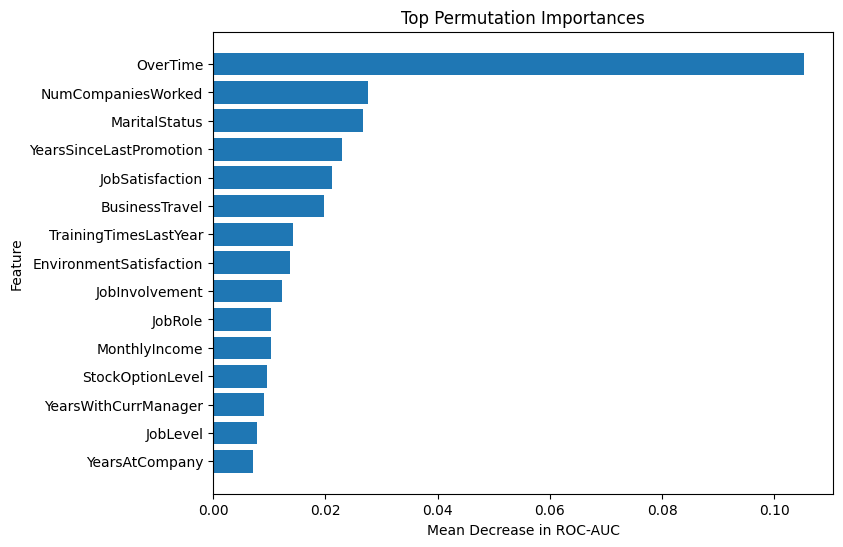

In [45]:
top_importance = importance_df.head(15).sort_values("importance_mean")

plt.figure(figsize=(8, 6))
plt.barh(top_importance["feature"], top_importance["importance_mean"])
plt.title("Top Permutation Importances")
plt.xlabel("Mean Decrease in ROC-AUC")
plt.ylabel("Feature")
plt.show()

## Feature Importance

Permutation importance estimates how much each original feature contributes to model performance.

The method works by randomly shuffling one feature at a time and measuring how much the model score drops.

A larger decrease in ROC-AUC means the feature is more important for predicting attrition risk.

The most important features were:

- `OverTime`
- `NumCompaniesWorked`
- `MaritalStatus`
- `YearsSinceLastPromotion`
- `JobSatisfaction`
- `BusinessTravel`
- `TrainingTimesLastYear`
- `EnvironmentSatisfaction`
- `JobInvolvement`
- `JobRole`

`OverTime` was the most important feature by a clear margin. This matches the EDA result, where employees who worked overtime had a much higher attrition rate.

The important features suggest that attrition risk is related to workload, career history, marital status, promotion history, satisfaction, travel, training, job involvement, and job role.

These features provide useful HR interpretation because they connect model predictions to factors that may affect employee retention.

In [46]:
risk_df = X_test.copy()
risk_df["actual_attrition"] = y_test
risk_df["attrition_probability"] = y_proba

risk_df["risk_band"] = pd.qcut(
    risk_df["attrition_probability"],
    q=5,
    labels=["Very Low", "Low", "Medium", "High", "Very High"]
)

risk_summary = (
    risk_df
    .groupby("risk_band")
    .agg(
        employees=("actual_attrition", "count"),
        actual_attrition_count=("actual_attrition", "sum"),
        attrition_rate=("actual_attrition", "mean"),
        avg_predicted_probability=("attrition_probability", "mean")
    )
    .reset_index()
)

risk_summary

,risk_band,employees,actual_attrition_count,attrition_rate,avg_predicted_probability
0,Very Low,59,2,0.033898,0.036567
1,Low,59,4,0.067797,0.134180
2,Medium,58,3,0.051724,0.270066
3,High,59,13,0.220339,0.482528
4,Very High,59,25,0.423729,0.786040


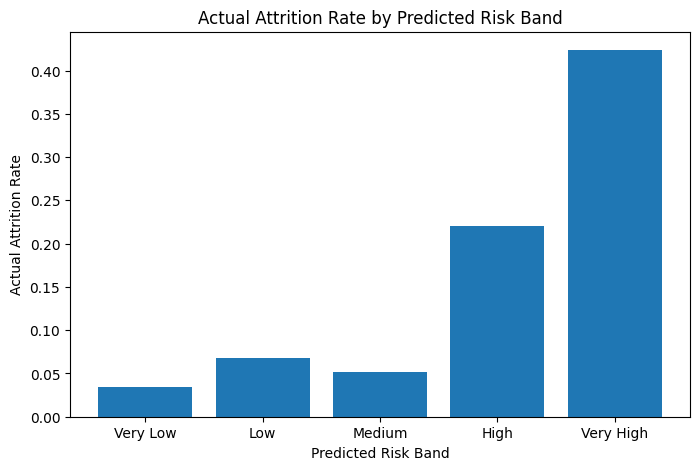

In [47]:
plt.figure(figsize=(8, 5))
plt.bar(risk_summary["risk_band"], risk_summary["attrition_rate"])
plt.title("Actual Attrition Rate by Predicted Risk Band")
plt.xlabel("Predicted Risk Band")
plt.ylabel("Actual Attrition Rate")
plt.show()

## Risk Band Analysis

The predicted attrition probabilities are grouped into five risk bands:

- Very Low
- Low
- Medium
- High
- Very High

This makes the model easier to interpret for HR decision-making.

The actual attrition rate increased across the risk bands:

- Very Low: 3.39%
- Low: 6.78%
- Medium: 5.17%
- High: 22.03%
- Very High: 42.37%

The Very High risk band had the highest attrition rate, while the Very Low and Low risk bands had much lower attrition rates.

The average predicted probability also increased clearly from 0.0366 in the Very Low band to 0.7860 in the Very High band.

This shows that the model is useful for ranking employees by attrition risk, even if the binary classification performance is not perfect.

Instead of only predicting whether an employee will leave, the model can help HR teams prioritize attention toward higher-risk groups.

In [48]:
error_df = X_test.copy()
error_df["actual"] = y_test
error_df["predicted"] = y_pred
error_df["attrition_probability"] = y_proba

false_positives = error_df[
    (error_df["actual"] == 0) &
    (error_df["predicted"] == 1)
].sort_values("attrition_probability", ascending=False)

false_negatives = error_df[
    (error_df["actual"] == 1) &
    (error_df["predicted"] == 0)
].sort_values("attrition_probability", ascending=True)

print("False positives:", false_positives.shape[0])
print("False negatives:", false_negatives.shape[0])

False positives: 56
False negatives: 17


In [49]:
false_positives.head(10)

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,actual,predicted,attrition_probability
310,31,Travel_Rarely,106,Human Resources,2,3,Human Resources,1,Male,62,2,2,Human Resources,1,Married,6410,17822,3,No,12,3,4,0,9,1,3,2,2,1,0,0,1,0.905531
929,28,Travel_Frequently,193,Research & Development,2,3,Life Sciences,4,Male,52,2,1,Laboratory Technician,4,Married,3867,14222,1,Yes,12,3,2,1,2,2,3,2,2,2,2,0,1,0.881975
824,42,Travel_Rarely,188,Research & Development,29,3,Medical,2,Male,56,1,2,Laboratory Technician,4,Single,4272,9558,4,No,19,3,1,0,16,3,3,1,0,0,0,0,1,0.876257
496,21,Travel_Rarely,1343,Sales,22,1,Technical Degree,3,Male,49,3,1,Sales Representative,3,Single,3447,24444,1,No,11,3,3,0,3,2,3,3,2,1,2,0,1,0.871623
301,18,Travel_Rarely,812,Sales,10,3,Medical,4,Female,69,2,1,Sales Representative,3,Single,1200,9724,1,No,12,3,1,0,0,2,3,0,0,0,0,0,1,0.858131
841,24,Travel_Rarely,477,Research & Development,24,3,Medical,4,Male,49,3,1,Laboratory Technician,2,Single,3597,6409,8,No,22,4,4,0,6,2,3,4,3,1,2,0,1,0.850592
1168,24,Travel_Frequently,567,Research & Development,2,1,Technical Degree,1,Female,32,3,1,Research Scientist,4,Single,3760,17218,1,Yes,13,3,3,0,6,2,3,6,3,1,3,0,1,0.849502
196,35,Travel_Frequently,138,Research & Development,2,3,Medical,2,Female,37,3,2,Laboratory Technician,2,Single,4425,15986,5,No,11,3,4,0,10,5,3,6,2,1,2,0,1,0.841754
1391,38,Travel_Rarely,1404,Sales,1,3,Life Sciences,1,Male,59,2,1,Sales Representative,1,Single,2858,11473,4,No,14,3,1,0,20,3,2,1,0,0,0,0,1,0.839155
347,47,Travel_Frequently,1309,Sales,4,1,Medical,2,Male,99,3,2,Sales Representative,3,Single,2976,25751,3,No,19,3,1,0,5,3,3,0,0,0,0,0,1,0.836112


In [50]:
false_negatives.head(10)

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,actual,predicted,attrition_probability
1111,53,Travel_Rarely,607,Research & Development,2,5,Technical Degree,3,Female,78,2,3,Manufacturing Director,4,Married,10169,14618,0,No,16,3,2,1,34,4,3,33,7,1,9,1,0,0.008242
126,58,Travel_Rarely,147,Research & Development,23,4,Medical,4,Female,94,3,3,Healthcare Representative,4,Married,10312,3465,1,No,12,3,4,1,40,3,2,40,10,15,6,1,0,0.044730
663,21,Travel_Rarely,1427,Research & Development,18,1,Other,4,Female,65,3,1,Research Scientist,4,Single,2693,8870,1,No,19,3,1,0,1,3,2,1,0,0,0,1,0,0.129729
45,41,Travel_Rarely,1360,Research & Development,12,3,Technical Degree,2,Female,49,3,5,Research Director,3,Married,19545,16280,1,No,12,3,4,0,23,0,3,22,15,15,8,1,0,0.146578
217,29,Travel_Rarely,992,Research & Development,1,3,Technical Degree,3,Male,85,3,1,Research Scientist,3,Single,2058,19757,0,No,14,3,4,0,7,1,2,6,2,1,5,1,0,0.188801
700,58,Travel_Rarely,289,Research & Development,2,3,Technical Degree,4,Male,51,3,1,Research Scientist,3,Single,2479,26227,4,No,24,4,1,0,7,4,3,1,0,0,0,1,0,0.206700
562,33,Travel_Rarely,527,Research & Development,1,4,Other,4,Male,63,3,1,Research Scientist,4,Single,2686,5207,1,Yes,13,3,3,0,10,2,2,10,9,7,8,1,0,0.230415
136,51,Travel_Frequently,1150,Research & Development,8,4,Life Sciences,1,Male,53,1,3,Manufacturing Director,4,Single,10650,25150,2,No,15,3,4,0,18,2,3,4,2,0,3,1,0,0.260513
779,51,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,Male,34,3,1,Research Scientist,3,Married,2461,10332,9,Yes,12,3,3,3,18,2,4,10,0,2,7,1,0,0.279245
789,44,Travel_Rarely,1376,Human Resources,1,2,Medical,2,Male,91,2,3,Human Resources,1,Married,10482,2326,9,No,14,3,4,1,24,1,3,20,6,3,6,1,0,0.398569


## Error Analysis

Error analysis helps explain where the model makes mistakes.

The model produced:

- 56 false positives
- 17 false negatives

False positives are employees predicted as likely to leave, but who actually stayed.

False negatives are employees predicted as likely to stay, but who actually left.

In an HR setting, false negatives may be especially important because the company misses employees who may need retention attention.

False positives also matter because they may cause unnecessary attention or intervention for employees who are not actually at high attrition risk.

The preferred balance between false positives and false negatives depends on the business goal. If HR wants to identify as many at-risk employees as possible, a lower threshold may be useful. If HR wants fewer false alarms, a higher threshold may be better.